# Advanced Heirarchical Clustering

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score, 
                             homogeneity_score, completeness_score, v_measure_score, 
                             adjusted_rand_score, normalized_mutual_info_score)

## Importing Dataset

In [2]:
data = pd.read_csv("/Users/anshumaansoni/PycharmProjects/Machine-Learning/Datasets/Iris.csv")

In [3]:
y = data["Species"]
X = data.drop(columns=["Id", "Species"])

In [4]:
display(data)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


## StandardScaler

In [4]:
sc = StandardScaler()
X = sc.fit_transform(X)

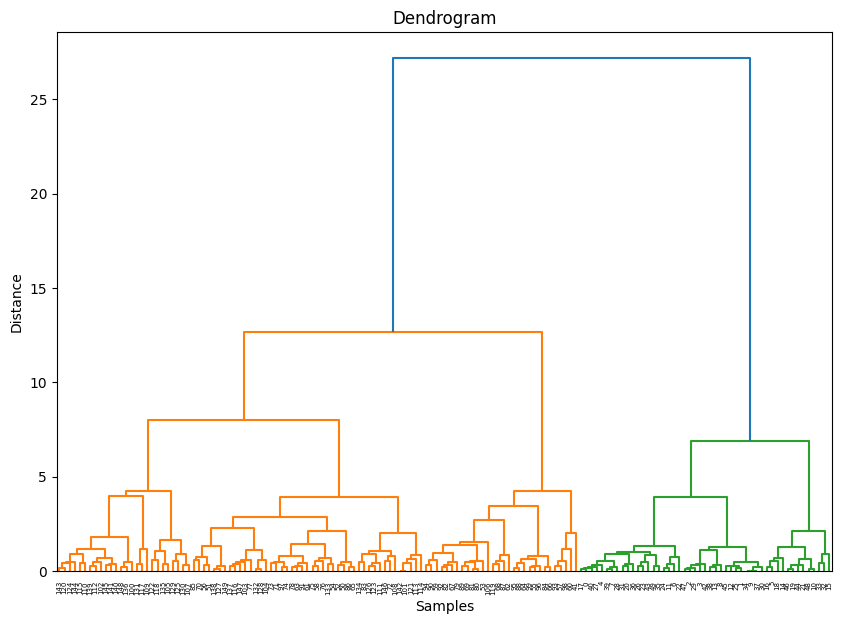

In [6]:
linked = linkage(X, method="ward")
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation="top", distance_sort="descending", show_leaf_counts=True)
plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

## Agglomerative Clustering

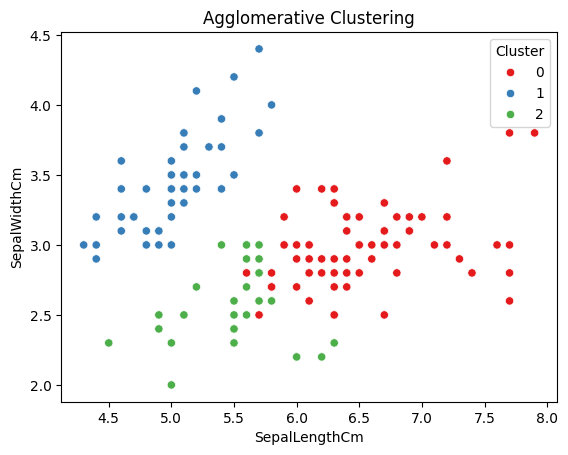

In [5]:
hc = AgglomerativeClustering(n_clusters=3, linkage="ward")
y_hc = hc.fit_predict(X)

data["Cluster"] = y_hc
sns.scatterplot(x=data["SepalLengthCm"], y=data["SepalWidthCm"], hue=data["Cluster"], palette="Set1")
plt.title("Agglomerative Clustering")
plt.show()

In [10]:
hc_score = silhouette_score(X, y_hc)
print(f"Silhouette Score for Agglomerative Clustering: {hc_score}")

Silhouette Score for Agglomerative Clustering: 0.44553956399200406


## Kmeans for Comparison

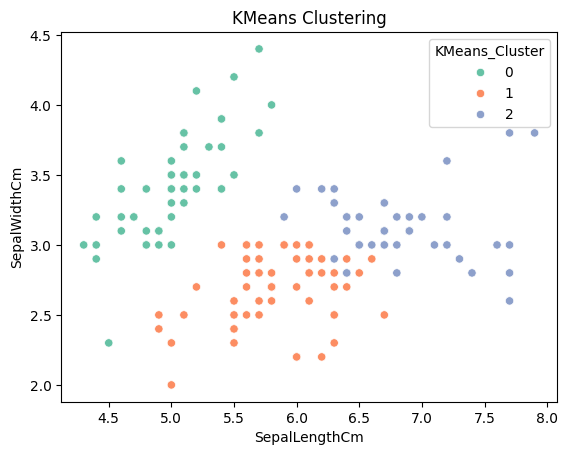

In [6]:
kmean = KMeans(n_clusters=3, random_state=234)
y_kmean = kmean.fit_predict(X)

data["KMeans_Cluster"] = y_kmean
sns.scatterplot(x=data["SepalLengthCm"], y=data["SepalWidthCm"], hue=data["KMeans_Cluster"], palette="Set2")
plt.title("KMeans Clustering")
plt.show()

In [12]:
kmean_score = silhouette_score(X, y_kmean)
print(f"Silhouette Score for KMeans Clustering: {kmean_score}")

Silhouette Score for KMeans Clustering: 0.46214947389312017


## Comprehensive Performance Metrics Comparison

In [7]:
# Convert Species to numeric labels for metrics calculation
y_true_numeric = pd.factorize(y)[0]

# Calculate metrics for Agglomerative Clustering
hc_metrics = {
    'Algorithm': 'Agglomerative Clustering',
    'Silhouette Score': silhouette_score(X, y_hc),
    'Davies-Bouldin Index': davies_bouldin_score(X, y_hc),
    'Calinski-Harabasz Index': calinski_harabasz_score(X, y_hc),
    'Homogeneity Score': homogeneity_score(y_true_numeric, y_hc),
    'Completeness Score': completeness_score(y_true_numeric, y_hc),
    'V-Measure Score': v_measure_score(y_true_numeric, y_hc),
    'Adjusted Rand Index': adjusted_rand_score(y_true_numeric, y_hc),
    'Normalized Mutual Info': normalized_mutual_info_score(y_true_numeric, y_hc)
}

# Calculate metrics for KMeans
kmean_metrics = {
    'Algorithm': 'KMeans',
    'Silhouette Score': silhouette_score(X, y_kmean),
    'Davies-Bouldin Index': davies_bouldin_score(X, y_kmean),
    'Calinski-Harabasz Index': calinski_harabasz_score(X, y_kmean),
    'Homogeneity Score': homogeneity_score(y_true_numeric, y_kmean),
    'Completeness Score': completeness_score(y_true_numeric, y_kmean),
    'V-Measure Score': v_measure_score(y_true_numeric, y_kmean),
    'Adjusted Rand Index': adjusted_rand_score(y_true_numeric, y_kmean),
    'Normalized Mutual Info': normalized_mutual_info_score(y_true_numeric, y_kmean)
}

# Create comparison dataframe
metrics_df = pd.DataFrame([hc_metrics, kmean_metrics])
print("\n" + "="*80)
print("CLUSTERING ALGORITHMS PERFORMANCE METRICS COMPARISON")
print("="*80)
print(metrics_df.to_string(index=False))
print("="*80)


CLUSTERING ALGORITHMS PERFORMANCE METRICS COMPARISON
               Algorithm  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index  Homogeneity Score  Completeness Score  V-Measure Score  Adjusted Rand Index  Normalized Mutual Info
Agglomerative Clustering          0.445540              0.805940               220.260437           0.657882            0.694025         0.675470             0.615323                0.675470
                  KMeans          0.462149              0.834022               238.924333           0.641251            0.644072         0.642658             0.592333                0.642658


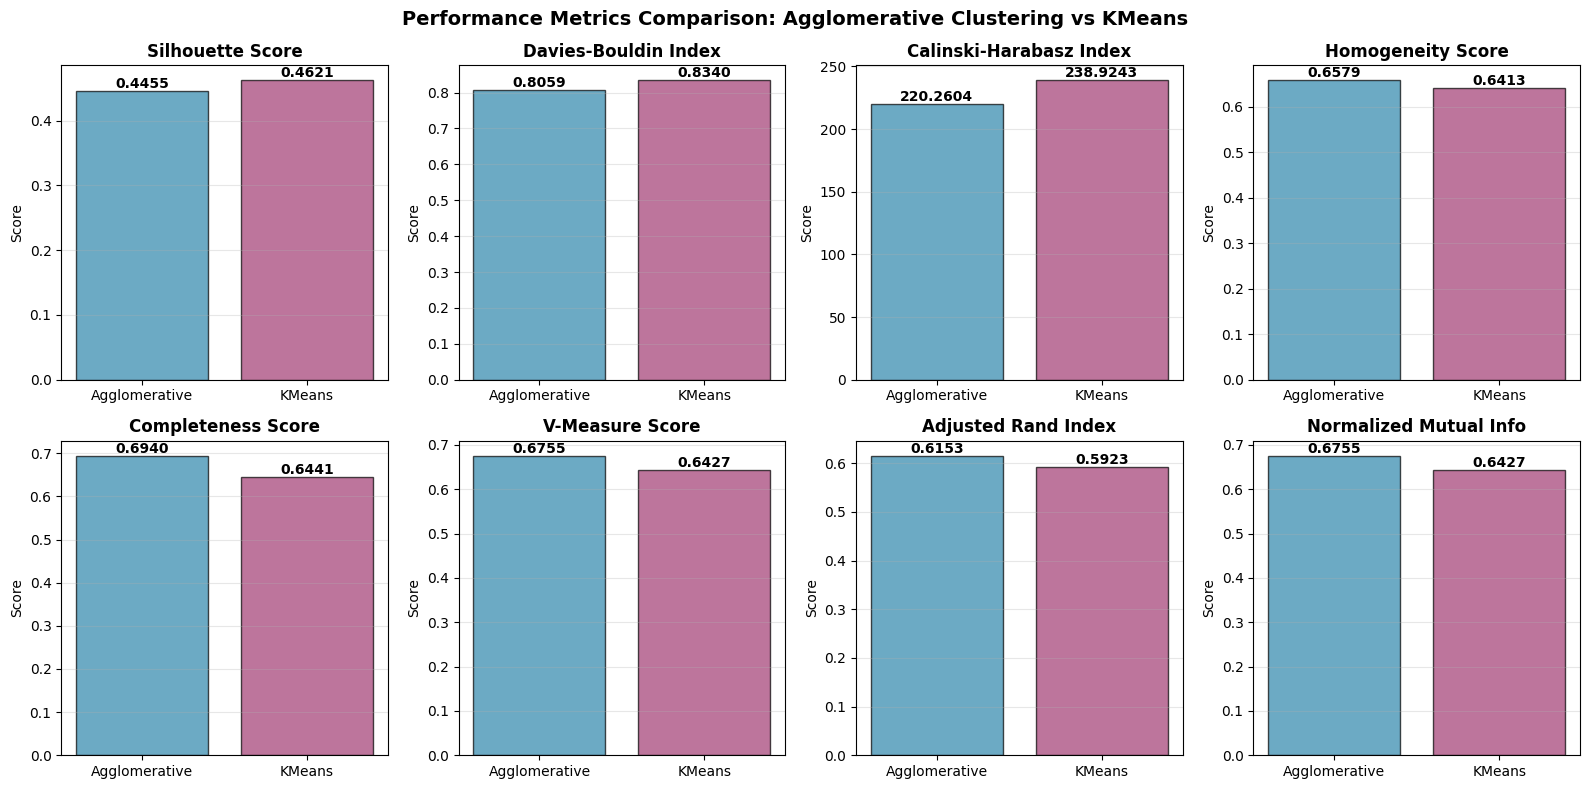


Metric Interpretation Guide:
--------------------------------------------------------------------------------
✓ Silhouette Score: Range [-1, 1]. Higher is better. Measures cluster cohesion.
✓ Davies-Bouldin Index: Lower is better. Measures cluster separation.
✓ Calinski-Harabasz Index: Higher is better. Ratio of between-cluster to within-cluster variance.
✓ Homogeneity Score: Range [0, 1]. Higher is better. Measures if each cluster contains only one class.
✓ Completeness Score: Range [0, 1]. Higher is better. Measures if all class members are in same cluster.
✓ V-Measure Score: Range [0, 1]. Higher is better. Harmonic mean of homogeneity and completeness.
✓ Adjusted Rand Index: Range [-1, 1]. Higher is better. Similarity to true labels, adjusted for chance.
✓ Normalized Mutual Info: Range [0, 1]. Higher is better. Mutual information normalized by entropy.


In [8]:
# Visualize metrics comparison
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Performance Metrics Comparison: Agglomerative Clustering vs KMeans', fontsize=14, fontweight='bold')

metrics_to_plot = [
    'Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index', 
    'Homogeneity Score', 'Completeness Score', 'V-Measure Score', 
    'Adjusted Rand Index', 'Normalized Mutual Info'
]

axes = axes.flatten()

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    values = [hc_metrics[metric], kmean_metrics[metric]]
    algorithms = ['Agglomerative', 'KMeans']
    colors = ['#2E86AB', '#A23B72']
    
    bars = ax.bar(algorithms, values, color=colors, alpha=0.7, edgecolor='black')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontweight='bold')
    
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nMetric Interpretation Guide:")
print("-" * 80)
print("✓ Silhouette Score: Range [-1, 1]. Higher is better. Measures cluster cohesion.")
print("✓ Davies-Bouldin Index: Lower is better. Measures cluster separation.")
print("✓ Calinski-Harabasz Index: Higher is better. Ratio of between-cluster to within-cluster variance.")
print("✓ Homogeneity Score: Range [0, 1]. Higher is better. Measures if each cluster contains only one class.")
print("✓ Completeness Score: Range [0, 1]. Higher is better. Measures if all class members are in same cluster.")
print("✓ V-Measure Score: Range [0, 1]. Higher is better. Harmonic mean of homogeneity and completeness.")
print("✓ Adjusted Rand Index: Range [-1, 1]. Higher is better. Similarity to true labels, adjusted for chance.")
print("✓ Normalized Mutual Info: Range [0, 1]. Higher is better. Mutual information normalized by entropy.")

In [9]:
# Detailed comparison and winner analysis
print("\n" + "="*80)
print("DETAILED ANALYSIS & RECOMMENDATIONS")
print("="*80)

print("\n1. INTERNAL VALIDATION METRICS (No True Labels Required):")
print("-" * 80)

# Silhouette Score comparison
print(f"   Silhouette Score:")
print(f"      Agglomerative: {hc_metrics['Silhouette Score']:.6f}")
print(f"      KMeans:        {kmean_metrics['Silhouette Score']:.6f}")
print(f"      Winner: {'Agglomerative' if hc_metrics['Silhouette Score'] > kmean_metrics['Silhouette Score'] else 'KMeans'}")

# Davies-Bouldin Index comparison (lower is better)
print(f"\n   Davies-Bouldin Index (Lower is Better):")
print(f"      Agglomerative: {hc_metrics['Davies-Bouldin Index']:.6f}")
print(f"      KMeans:        {kmean_metrics['Davies-Bouldin Index']:.6f}")
print(f"      Winner: {'Agglomerative' if hc_metrics['Davies-Bouldin Index'] < kmean_metrics['Davies-Bouldin Index'] else 'KMeans'}")

# Calinski-Harabasz Index comparison
print(f"\n   Calinski-Harabasz Index (Higher is Better):")
print(f"      Agglomerative: {hc_metrics['Calinski-Harabasz Index']:.6f}")
print(f"      KMeans:        {kmean_metrics['Calinski-Harabasz Index']:.6f}")
print(f"      Winner: {'Agglomerative' if hc_metrics['Calinski-Harabasz Index'] > kmean_metrics['Calinski-Harabasz Index'] else 'KMeans'}")

print("\n2. EXTERNAL VALIDATION METRICS (Using True Labels):")
print("-" * 80)

print(f"   Homogeneity Score:")
print(f"      Agglomerative: {hc_metrics['Homogeneity Score']:.6f}")
print(f"      KMeans:        {kmean_metrics['Homogeneity Score']:.6f}")
print(f"      Winner: {'Agglomerative' if hc_metrics['Homogeneity Score'] > kmean_metrics['Homogeneity Score'] else 'KMeans'}")

print(f"\n   Completeness Score:")
print(f"      Agglomerative: {hc_metrics['Completeness Score']:.6f}")
print(f"      KMeans:        {kmean_metrics['Completeness Score']:.6f}")
print(f"      Winner: {'Agglomerative' if hc_metrics['Completeness Score'] > kmean_metrics['Completeness Score'] else 'KMeans'}")

print(f"\n   V-Measure Score (Harmonic Mean):")
print(f"      Agglomerative: {hc_metrics['V-Measure Score']:.6f}")
print(f"      KMeans:        {kmean_metrics['V-Measure Score']:.6f}")
print(f"      Winner: {'Agglomerative' if hc_metrics['V-Measure Score'] > kmean_metrics['V-Measure Score'] else 'KMeans'}")

print(f"\n   Adjusted Rand Index:")
print(f"      Agglomerative: {hc_metrics['Adjusted Rand Index']:.6f}")
print(f"      KMeans:        {kmean_metrics['Adjusted Rand Index']:.6f}")
print(f"      Winner: {'Agglomerative' if hc_metrics['Adjusted Rand Index'] > kmean_metrics['Adjusted Rand Index'] else 'KMeans'}")

print(f"\n   Normalized Mutual Information:")
print(f"      Agglomerative: {hc_metrics['Normalized Mutual Info']:.6f}")
print(f"      KMeans:        {kmean_metrics['Normalized Mutual Info']:.6f}")
print(f"      Winner: {'Agglomerative' if hc_metrics['Normalized Mutual Info'] > kmean_metrics['Normalized Mutual Info'] else 'KMeans'}")

print("\n" + "="*80)


DETAILED ANALYSIS & RECOMMENDATIONS

1. INTERNAL VALIDATION METRICS (No True Labels Required):
--------------------------------------------------------------------------------
   Silhouette Score:
      Agglomerative: 0.445540
      KMeans:        0.462149
      Winner: KMeans

   Davies-Bouldin Index (Lower is Better):
      Agglomerative: 0.805940
      KMeans:        0.834022
      Winner: Agglomerative

   Calinski-Harabasz Index (Higher is Better):
      Agglomerative: 220.260437
      KMeans:        238.924333
      Winner: KMeans

2. EXTERNAL VALIDATION METRICS (Using True Labels):
--------------------------------------------------------------------------------
   Homogeneity Score:
      Agglomerative: 0.657882
      KMeans:        0.641251
      Winner: Agglomerative

   Completeness Score:
      Agglomerative: 0.694025
      KMeans:        0.644072
      Winner: Agglomerative

   V-Measure Score (Harmonic Mean):
      Agglomerative: 0.675470
      KMeans:        0.642658
   